<!-- @format -->

# 04 - Final Evaluation & Visualization

Notebook này thực hiện đánh giá cuối cùng trên 2 mô hình: **Linear Regression** và **Random Forest**.

1. Tổng hợp metrics trên test set
2. Vẽ biểu đồ **Actual vs Predicted**
3. Vẽ **Residual Plot**
4. Phân tích **Feature Importance**
5. Xuất kết quả ra báo cáo


<!-- @format -->

## 1. Setup & Load Data


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    X_TEST_FILE, Y_TEST_FILE, TARGET_COL, MODELS_DIR, FIGURES_DIR, TABLES_DIR
)
from src.utils import load_model, ensure_dir
from src.evaluate import (
    plot_actual_vs_predicted, plot_residuals, 
    plot_feature_importance, plot_model_comparison
)

sns.set_theme(style="whitegrid")

# Load test data
X_test = pd.read_csv(X_TEST_FILE)
y_test = pd.read_csv(Y_TEST_FILE)[TARGET_COL]
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")

Test set: 2093 samples, 17 features


<!-- @format -->

## 2. Đánh giá tất cả mô hình trên Test Set


In [2]:
# Load tất cả models đã lưu
model_paths = {
    "Linear Regression": MODELS_DIR / "baseline" / "linear_regression.joblib",
    "Random Forest": MODELS_DIR / "baseline" / "random_forest.joblib",
}

# Đánh giá từng model
results = []
predictions = {}

for name, path in model_paths.items():
    if not path.exists():
        print(f"SKIP: {name} - chưa train (file không tồn tại)")
        continue
    model = load_model(path)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
    })
    predictions[name] = y_pred
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df)

Linear Regression: MAE=1804.90, RMSE=2302.48, R²=0.6198
Random Forest: MAE=1065.89, RMSE=1530.99, R²=0.8319


,Model,MAE,RMSE,R2
0,Random Forest,1065.89,1530.99,0.8319
1,Linear Regression,1804.90,2302.48,0.6198


<!-- @format -->

## 3. Biểu đồ so sánh các mô hình


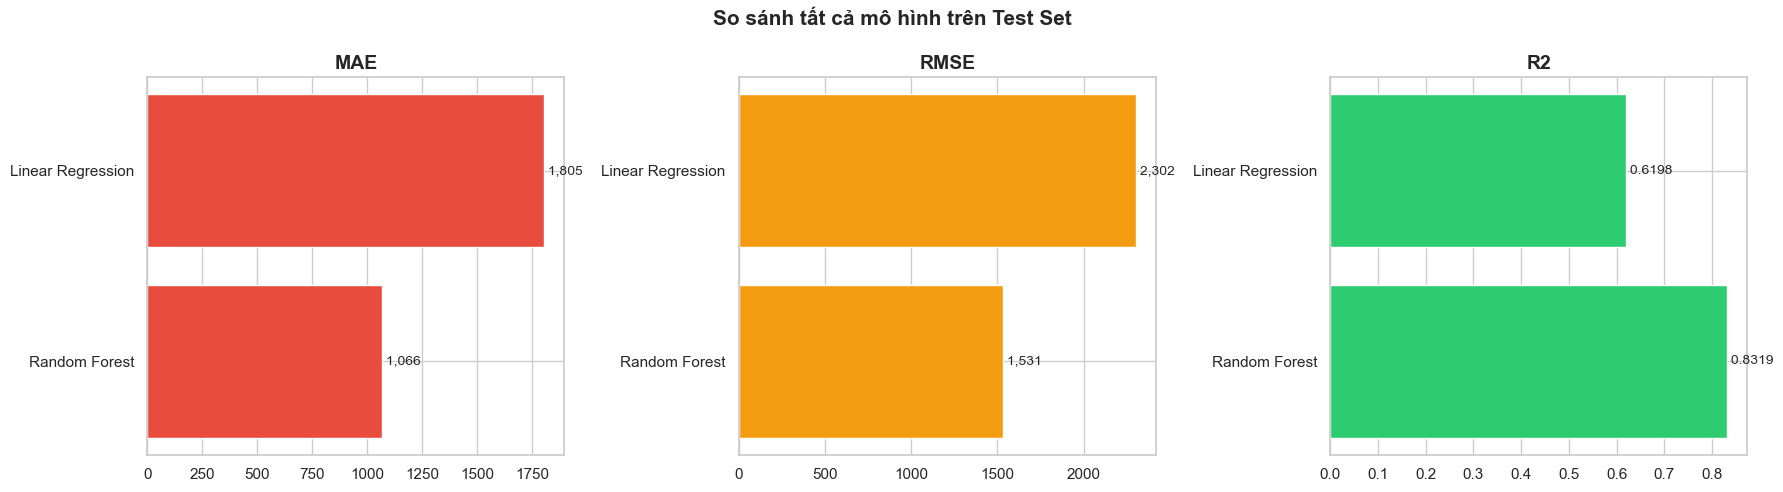

In [3]:
# So sánh theo 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_info = [
    ("MAE", "#e74c3c", True),
    ("RMSE", "#f39c12", True),
    ("R2", "#2ecc71", False),
]

for ax, (metric, color, asc) in zip(axes, metrics_info):
    df_sorted = results_df.sort_values(metric, ascending=asc)
    ax.barh(df_sorted["Model"], df_sorted[metric], color=color, edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    for i, v in enumerate(df_sorted[metric]):
        fmt = f"{v:.4f}" if metric == "R2" else f"{v:,.0f}"
        ax.text(v, i, f" {fmt}", va="center", fontsize=10)

plt.suptitle("So sánh tất cả mô hình trên Test Set", fontsize=15, fontweight="bold")
plt.tight_layout()
ensure_dir(FIGURES_DIR)
plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<!-- @format -->

## 4. Actual vs Predicted - Mô hình tốt nhất


Mô hình tốt nhất: Random Forest


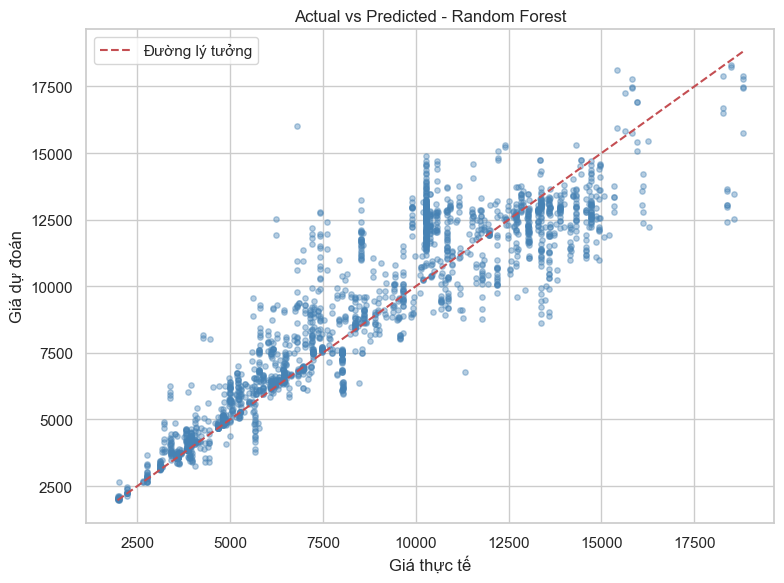

In [4]:
# Tìm model tốt nhất (R² cao nhất)
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]
print(f"Mô hình tốt nhất: {best_model_name}")

# Actual vs Predicted
plot_actual_vs_predicted(
    y_test, best_pred,
    title=f"Actual vs Predicted - {best_model_name}",
    save_path=FIGURES_DIR / "actual_vs_predicted.png"
)

<!-- @format -->

## 5. Residual Plot


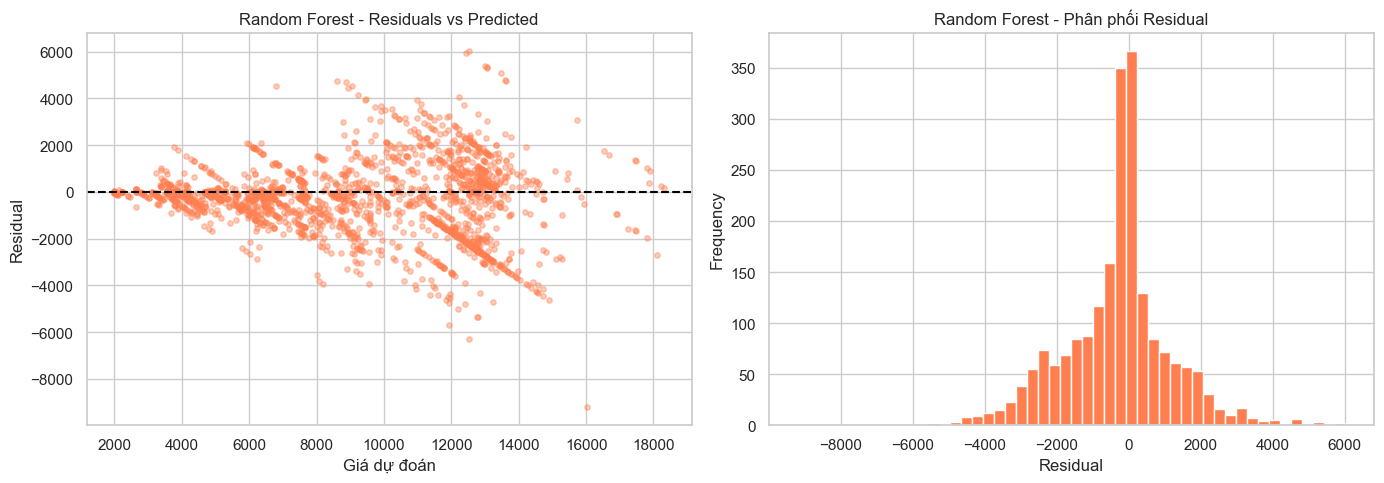

In [5]:
plot_residuals(
    y_test, best_pred,
    title=best_model_name,
    save_path=FIGURES_DIR / "residual_plot.png"
)

<!-- @format -->

## 6. Feature Importance


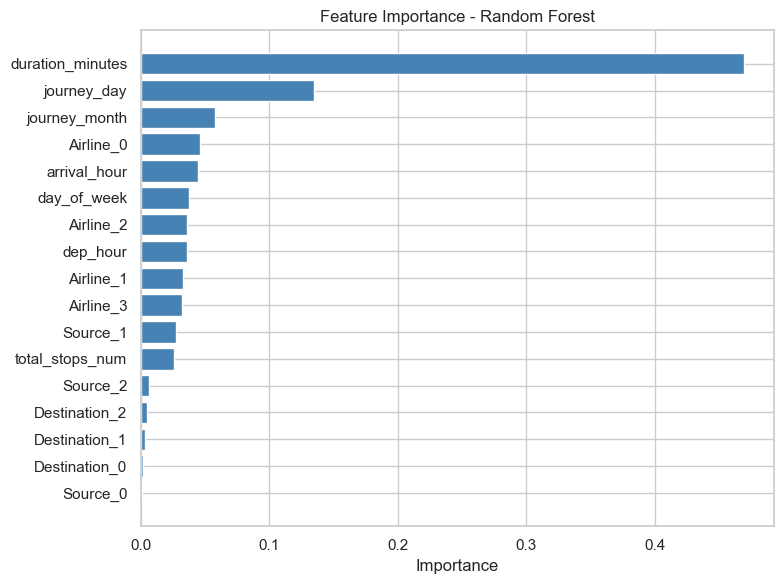

In [6]:
# Lấy model gốc (bên trong pipeline) để trích feature importance
best_path = model_paths[best_model_name]
best_pipeline = load_model(best_path)

# Trích model từ pipeline (bước cuối cùng)
inner_model = best_pipeline[-1] if hasattr(best_pipeline, '__getitem__') else best_pipeline

if hasattr(inner_model, "feature_importances_"):
    plot_feature_importance(
        inner_model,
        list(X_test.columns),
        top_n=31,
        title=f"Feature Importance - {best_model_name}",
        save_path=FIGURES_DIR / "feature_importance.png"
    )
else:
    print(f"{best_model_name} không hỗ trợ feature_importances_")

<!-- @format -->

## 7. Xuất kết quả báo cáo


In [7]:
# Lưu bảng so sánh cuối cùng
ensure_dir(TABLES_DIR)
results_df.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
print(f"Đã lưu bảng so sánh: {TABLES_DIR / 'model_comparison.csv'}")
print(f"Đã lưu biểu đồ: {FIGURES_DIR}")

print("\n" + "="*50)
print("KẾT QUẢ CUỐI CÙNG")
print("="*50)
display(results_df)
print(f"\nMô hình tốt nhất: {best_model_name}")
print(f"  R²   = {results_df.iloc[0]['R2']}")
print(f"  RMSE = {results_df.iloc[0]['RMSE']}")
print(f"  MAE  = {results_df.iloc[0]['MAE']}")

Đã lưu bảng so sánh: D:\Data_Mining\DataMining-FlightPricePrediction\reports\tables\model_comparison.csv
Đã lưu biểu đồ: D:\Data_Mining\DataMining-FlightPricePrediction\reports\figures

KẾT QUẢ CUỐI CÙNG


,Model,MAE,RMSE,R2
0,Random Forest,1065.89,1530.99,0.8319
1,Linear Regression,1804.90,2302.48,0.6198



Mô hình tốt nhất: Random Forest
  R²   = 0.8319
  RMSE = 1530.99
  MAE  = 1065.89


<!-- @format -->

## Tổng kết

| Bước | Notebook                             | Mô tả                                                          |
| ---- | ------------------------------------ | -------------------------------------------------------------- |
| 1    | 01_data_understanding                | Khám phá dữ liệu, phân phối giá, phân tích theo hãng/điểm dừng |
| 2    | 02_data_cleaning_feature_engineering | Làm sạch, tạo features, one-hot encoding, tách train/test      |
| 3    | 03_baseline_models                   | Train Linear Regression & Random Forest, so sánh kết quả       |
| 4    | 04_final_evaluation_visualization    | Đánh giá cuối, biểu đồ, feature importance                     |

**Kết luận:** Random Forest cho kết quả vượt trội so với Linear Regression trong bài toán dự đoán giá vé máy bay, do giá vé có quan hệ phi tuyến phức tạp với các đặc trưng đầu vào.
